# ExG CLI Test

`services/forest_mask/cli.py` の `main` をプロジェクトルートから実行する想定でテストする。

- 入力: `data/input/jpg/sample/sample_tree.jpg`
- 出力: `data/intermediate/exg/exg_<timestamp>.jpg`

In [1]:
# プロジェクトルートで実行できるようにカレントを移動
import os
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
    os.chdir(PROJECT_ROOT)

print("cwd:", Path.cwd())

cwd: /home/mqsol/works/forest-analyzer


In [2]:
# モジュールリロードを有効化（実装変更を即反映するため）
%load_ext autoreload
%autoreload 2

In [3]:
from click.testing import CliRunner

from services.forest_mask.cli import main

INPUT_PATH = "data/input/jpg/sample/sample_tree.jpg"

runner = CliRunner()
result = runner.invoke(main, [INPUT_PATH], catch_exceptions=False)

print(result.output)
assert result.exit_code == 0, f"exit_code={result.exit_code}"

Saved: data/intermediate/exg/exg_20260514173719.jpg



latest: data/intermediate/exg/exg_20260514173719.jpg


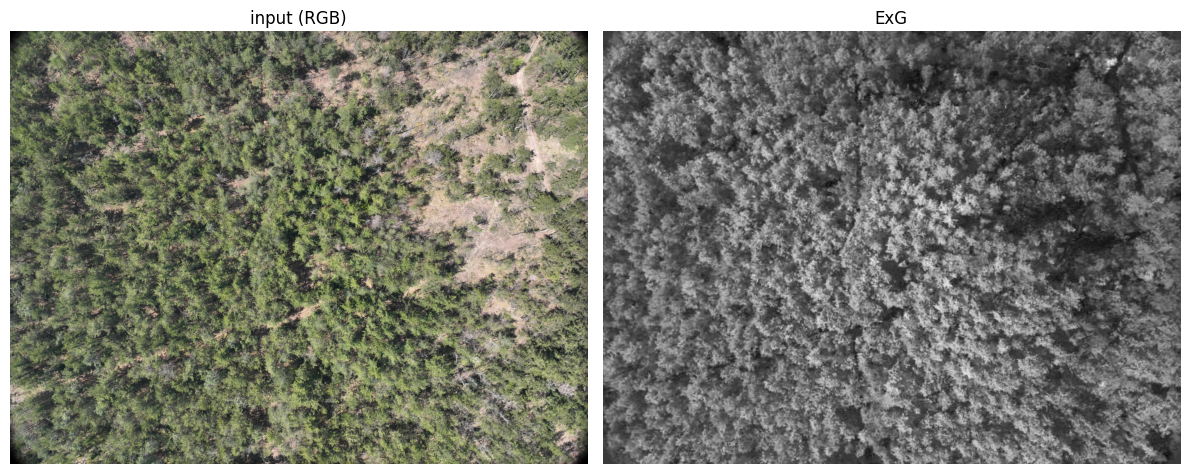

In [4]:
# 出力結果の確認: 最新の ExG 画像を入力と並べて表示
import matplotlib.pyplot as plt

from services.common.image import load_rgb

output_dir = Path("data/intermediate/exg")
latest = max(output_dir.glob("exg_*.jpg"), key=lambda p: p.stat().st_mtime)
print("latest:", latest)

rgb = load_rgb(Path(INPUT_PATH))
exg = load_rgb(latest)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(rgb)
axes[0].set_title("input (RGB)")
axes[0].axis("off")
axes[1].imshow(exg)
axes[1].set_title("ExG")
axes[1].axis("off")
plt.tight_layout()
plt.show()